In [2]:
!pip install xgboost imbalanced-learn shap

In [3]:
# ==========================================================
# Cell 2 - Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

print("="*60)
print("Notebook 6 Started")
print("="*60)

Notebook 6 Started


In [4]:
# ==========================================================
# Cell 3 - Load Training Dataset
# ==========================================================

PROJECT_DIR = Path("/Users/rajdeepmandal/Desktop/PrithviX")

PROCESSED_DIR = PROJECT_DIR / "Processed"

dataset = pd.read_csv(
    PROCESSED_DIR / "training_dataset.csv"
)

print("="*60)
print("Dataset Loaded")
print("="*60)

print("Shape :", dataset.shape)

display(dataset.head())

Dataset Loaded
Shape : (50931, 5)


,DEM,NDVI,Soil,Population,Landslide
0,61.0,0.414891,0.0,8.558760,0
1,86.0,0.879887,0.0,0.856890,0
2,255.0,0.574537,0.0,5.735787,0
3,1895.0,0.876970,0.0,0.014362,0
4,600.0,0.883863,0.0,0.651973,0


In [5]:
# ==========================================================
# Cell 4 - Train/Test Split
# ==========================================================

X = dataset.drop(columns=["Landslide"])

y = dataset["Landslide"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("="*60)
print("Dataset Split")
print("="*60)

print("Training :", X_train.shape)
print("Testing  :", X_test.shape)

print("\nTraining Class Distribution")

print(y_train.value_counts())

Dataset Split
Training : (40744, 4)
Testing  : (10187, 4)

Training Class Distribution
Landslide
0    39999
1      745
Name: count, dtype: int64


In [6]:
# ==========================================================
# Cell 5 - Calculate Class Weight
# ==========================================================

negative = np.sum(y_train == 0)
positive = np.sum(y_train == 1)

scale_pos_weight = negative / positive

print("="*60)
print("Class Balance")
print("="*60)

print("Negative :", negative)
print("Positive :", positive)

print("\nscale_pos_weight =", round(scale_pos_weight,2))

Class Balance
Negative : 39999
Positive : 745

scale_pos_weight = 53.69


In [7]:
from xgboost import XGBClassifier

print("="*60)
print("Training Optimized XGBoost...")
print("="*60)

xgb = XGBClassifier(
    objective="binary:logistic",

    # Trees
    n_estimators=500,
    max_depth=8,

    # Learning
    learning_rate=0.05,

    # Regularization
    min_child_weight=3,
    gamma=0.2,

    # Sampling
    subsample=0.8,
    colsample_bytree=0.8,

    # Handle Imbalance
    scale_pos_weight=scale_pos_weight,

    # Speed
    tree_method="hist",
    n_jobs=-1,

    random_state=42,
    eval_metric="auc"
)

xgb.fit(X_train, y_train)

print("\nTraining Completed Successfully!")

Training Optimized XGBoost...

Training Completed Successfully!


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("="*60)
print("XGBOOST PERFORMANCE")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test,y_prob):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test,y_pred))

XGBOOST PERFORMANCE
Accuracy : 0.9782
Precision: 0.4455
Recall   : 0.7903
F1 Score : 0.5698
ROC AUC  : 0.9831

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     10001
           1       0.45      0.79      0.57       186

    accuracy                           0.98     10187
   macro avg       0.72      0.89      0.78     10187
weighted avg       0.99      0.98      0.98     10187


Confusion Matrix

[[9818  183]
 [  39  147]]


,Feature,Importance
0,DEM,0.495739
3,Population,0.318224
1,NDVI,0.186037
2,Soil,0.000000


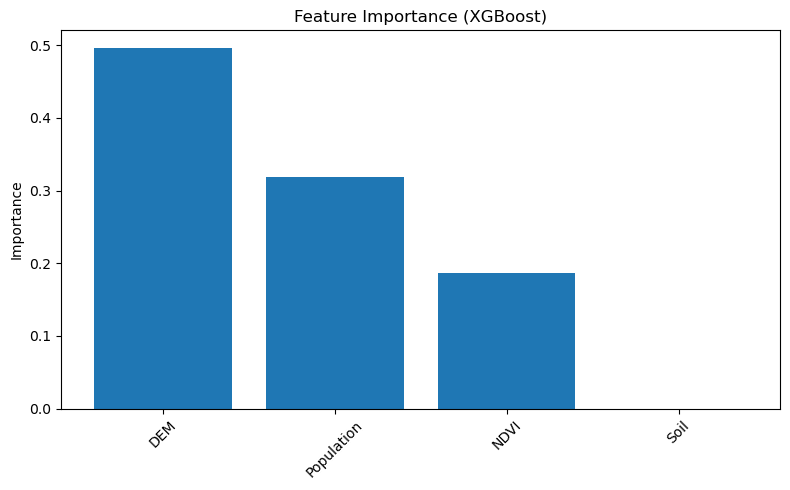

In [9]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(8,5))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance (XGBoost)")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
MODEL_DIR = PROJECT_DIR / "Models"
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "landslide_xgboost.pkl"

joblib.dump(xgb, model_path)

print("="*60)
print("MODEL SAVED")
print("="*60)
print(model_path)

MODEL SAVED
/Users/rajdeepmandal/Desktop/PrithviX/Models/landslide_xgboost.pkl


In [12]:
sample = X_test.iloc[[0]]

probability = xgb.predict_proba(sample)[0][1]
risk = probability * 100

if risk < 20:
    level = "Very Low"
elif risk < 40:
    level = "Low"
elif risk < 60:
    level = "Moderate"
elif risk < 80:
    level = "High"
else:
    level = "Very High"

print("="*60)
print("LANDSLIDE RISK PREDICTION")
print("="*60)

print(f"Risk Probability : {risk:.2f}%")
print(f"Risk Level       : {level}")
print(f"Prediction        : {'LANDSLIDE' if probability >= 0.5 else 'NO LANDSLIDE'}")

print("\nInput Features")
display(sample)

LANDSLIDE RISK PREDICTION
Risk Probability : 0.01%
Risk Level       : Very Low
Prediction        : NO LANDSLIDE

Input Features


,DEM,NDVI,Soil,Population
49706,15.0,0.295014,0.0,8.837237
